<a href="https://colab.research.google.com/github/Teresa-Shah/5610_Assignments/blob/main/Final_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chemical Applications of Machine Learning (CHEM 4930/5610) - Spring 2026

### Assignment 2 - Deadline 2/3/2026
Points 10

#### General Comments
All figures and graph should have approriate labels on the two axis, and should include a legend with appropriate labels of the different plots.

The notebook should be return in working format. That is, I should be able to reset all the output and re-run all the cells and get the same results as you obtained.

**You should start by saving a copy of the notebook to your Google Drive so you preserve all changes.**

**Please add your name as a suffix to the filname**

**Student Name**: Teresa Shah

**AI usage statement:**
ChatGpt
Used chatgpt for understanding the codes. Used to understand some of the pacakages and how to use them in a simple way. Sometime to generate the code giving it directions.

### Task 1 - 10 points

In this task, we will consider the Bradley Melting Point Dataset, which is curated chemical dataset with melting points of around 3,000 chemical compounds, see [here](https://www.kaggle.com/datasets/aliffaagnur/melting-point-chemical-dataset/data).

This dataset is stored in a comma-separated values (csv) file, which is common format used to start data in text files. We can load this into a pandas DataFrame using the `load_csv` function.

In this dataset, we have the compounds names, SMILES strings, and the melting point in Celsius.

#### A)
Identify in the dataset the chemical compounds with the 5 lowest melting points and 5 highest melting points and visualize their 2D chemical structure using RDKit and the [mols2grid package](https://mols2grid.readthedocs.io/en/latest/), where you display the melting point values on the grid, see [here](https://colab.research.google.com/github/PatWalters/practical_cheminformatics_tutorials/blob/main/fundamentals/A_Whirlwind_Introduction_To_The_RDKit.ipynb#scrollTo=N3CR7rMF3sg7) for an example of the usage of mols2grid.

#### B)
Calculate the following properties for the molecules using RDKIt:
- The molecular weight
- The number of heavy atoms
- Number of hydrogen bond acceptors
- Number of hydrogen bond donors
- [Octanol-water partition coefficient - LogP](https://pubs-acs-org.libproxy.library.unt.edu/doi/10.1021/ci990307l)
- [Topological polar surface area (TPSA) descriptor](https://pubs-acs-org.libproxy.library.unt.edu/doi/abs/10.1021/jm000942e)
- Topological polar surface area (TPSA) descriptor, including S and P atoms, see [here](https://www.rdkit.org/docs/RDKit_Book.html#implementation-of-the-tpsa-descriptor)

Note: for some of the molecules, the TPSA descriptor will give a value of zero. When doing any analysis for the TPSA descriptor, you should ignore these values.

#### C)
Write out to a new csv file values of all the properties calculated in B) along with the compound names, SMILES strings, and the melting point in Celsius. Here, when writing this file, you should ignore any compounds where the SMILES conversion did not work correctly.

#### D)
Perform a linear regression analysis using scikit-learn where you look at the correlation of each of the properties calculated in B) with melting temperature. Here, each property should be considered individually.

To avoid outliers, filter out (i.e., remove) the compounds with the lowest 10% and the highest 10% melting temperature. Make a histogram that shows this filtering. Furthermore, for each property, filter out the compounds with lowest 10% and highest 10% values (again making a histogram that shows this filtering). Only consider the joint remaining compounds in your linear regression analysis for each property.

When performing the linear regression, employ a 70%/30% training/test split.

Calculate the coefficient of determination, $R^2$, for both the training dataset and the test dataset and report both.

You should make figure that shows the data along with the linear curve coming from the linear regression. In the figure, it should be clear which data points are in the training and test set (e.g., by having them in different colors). Include the $R^2$ values on the figure.

From your analysis, which of the properties correlates best with the melting temperature?

#### E)
For two of the properties from D) (e.g., the ones that correlate best with the melting point), perform [RANSAC](https://en.wikipedia.org/wiki/Random_sample_consensus) regression, which is method that takes outliers into account when performing linear regression and does not include them in the final modeling, see [here](https://scikit-learn.org/stable/auto_examples/linear_model/plot_ransac.html).

In the figure, it should be clear which data points are in inlier set and which are in the outlier set (e.g., by showing them in different colors).


A.
Identify in the dataset the chemical compounds with the 5 lowest melting points and 5 highest melting points and visualize their 2D chemical structure using RDKit and the mols2grid package, where you display the melting point values on the grid, see here for an example of the usage of mols2grid.

In [ ]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-2/"
dataset_filename="BradleyDoublePlusGoodMeltingPointDataset.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

BradleyDoublePlusGoodMeltingPointDataset.csv
BradleyMP_with_descriptors.csv
Dataset_RotatedWQ-Potential.data
sample_data


In [ ]:
%%capture
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit pandas seaborn mols2grid requests

In [ ]:
import pandas as pd
import numpy as np
import mols2grid

In [ ]:
# Load dataset
df = pd.read_csv("BradleyDoublePlusGoodMeltingPointDataset.csv")

In [ ]:
!head BradleyDoublePlusGoodMeltingPointDataset.csv

key,name,smiles,mpC,csid,link,source,count,min,max,range
27956,cyclobutylmethane,C1(CCC1)C,-161.51,11232,http://pubs.acs.org/doi/abs/10.1021/ja01142a048,Lemaire HP; Livingston RL Journal of the American Chemical Society; 74(22); 5732-5736 (1952),2,-161.51,-161.5,0.009999999999990905
16005,Nitrogen oxide,[O-][N+]#N,-90.8,923,http://msds.chem.ox.ac.uk/,academic website,2,-90.81,-90.8,0.010000000000005116
16127,Sulfuryl difluoride,FS(F)(=O)=O,-135.8,16647,http://msds.chem.ox.ac.uk/,academic website,2,-135.82,-135.8,0.01999999999998181
17138,disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.8,3002,http://dx.doi.org/10.1021/ci700307p,Hughes LD; Palmer DS; Nigsch F and Mitchell JBO. 2008 Why are some properties more difficult to predict than others? A study of QSPR models of solubility; melting point and LogP. J. Chem. Inf. Model. 2008. 48 (1). pp 220?285,2,94.75,94.8,0.04999999999999716
15628,Bromine,BrBr,-7.2,22817,http://msds.chem.ox.ac.uk/,academic website,2,-7.25,-7.2,0.0499999

In [ ]:
print(list(df.keys()))

['key', 'name', 'smiles', 'mpC', 'csid', 'link', 'source', 'count', 'min', 'max', 'range']


In [ ]:
from rdkit import Chem

In [ ]:
# Sort by melting point
df_sorted = df.sort_values("mpC")

# 5 lowest and 5 highest melting points
df_extremes = pd.concat([
    df_sorted.head(5),
    df_sorted.tail(5)
])

# Convert SMILES to RDKit molecules
df_extremes["Mol"] = df_extremes["smiles"].apply(Chem.MolFromSmiles)

# Drop failed SMILES
df_extremes = df_extremes.dropna(subset=["Mol"])

# Display with mols2grid
mols2grid.display(
    df_extremes,
    mol_col="Mol",
    subset=["name", "mpC"],
    tooltip=["name", "mpC"]
)




B)

Calculate the following properties for the molecules using RDKIt:

The molecular weight
The number of heavy atoms
Number of hydrogen bond acceptors
Number of hydrogen bond donors
Octanol-water partition coefficient - LogP
Topological polar surface area (TPSA) descriptor
Topological polar surface area (TPSA) descriptor, including S and P atoms, see here

Note: for some of the molecules, the TPSA descriptor will give a value of zero. When doing any analysis for the TPSA descriptor, you should ignore these values.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen
from rdkit.Chem.rdMolDescriptors import CalcTPSA


In [ ]:
#print("Descriptors.__")
#for des in Descriptors._descList: print("-",des[0])


In [ ]:
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return {
            "MolWt": np.nan,
            "HeavyAtoms": np.nan,
            "HBA": np.nan,
            "HBD": np.nan,
            "LogP": np.nan,
            "TPSA": np.nan,
            "TPSA_SP": np.nan
        }

    return {
        "MolWt": Descriptors.MolWt(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "HBA": Lipinski.NumHAcceptors(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": CalcTPSA(mol),
        "TPSA_SP": CalcTPSA(mol, includeSandP=True)
    }


In [ ]:
desc_list = df["smiles"].apply(calc_descriptors)
desc_df = pd.DataFrame(desc_list.tolist())
df_desc = pd.concat([df, desc_df], axis=1)

# Drop failed SMILES conversions
df_desc = df_desc.dropna()


[02:39:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 24 25 26 27 28 31 32 33 34
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[02:39:14] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 8
[02:39:15] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[02:39:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[02:39:15] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[02:39:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 12 13 14 15 16
[02:39:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[02:39:16] Can't kekulize mol.  Unkekuliz

In [ ]:
print("Original size:", len(df))
print("After descriptor calc:", len(df_desc))


Original size: 3041
After descriptor calc: 3025


In [ ]:
#Drop failed SMILES conversions (descriptor NaNs only)
descriptor_cols = ["name", "MolWt", "HeavyAtoms", "HBA", "HBD", "LogP", "TPSA", "TPSA_SP"]
df_desc = df_desc.dropna(subset=descriptor_cols)


In [ ]:
df_desc[descriptor_cols]



,name,MolWt,HeavyAtoms,HBA,HBD,LogP,TPSA,TPSA_SP
0,cyclobutylmethane,70.135,5.0,0.0,0.0,1.80640,0.00,0.00
1,Nitrogen oxide,44.013,3.0,2.0,0.0,0.33728,51.21,51.21
2,Sulfuryl difluoride,102.061,5.0,2.0,0.0,0.17020,34.14,42.52
3,disopyramide,339.483,25.0,3.0,1.0,3.36190,59.22,59.22
4,Bromine,159.808,2.0,0.0,0.0,1.69120,0.00,0.00
...,...,...,...,...,...,...,...,...
3036,4-Nitrobenzoic acid,167.120,12.0,3.0,1.0,1.29300,80.44,80.44
3037,Thalidomide,258.233,19.0,4.0,1.0,0.08780,83.55,83.55
3038,Estradiol,272.388,20.0,2.0,2.0,3.60920,40.46,40.46
3039,"2,4,6-Trichlorophenol",197.448,10.0,1.0,1.0,3.35240,20.23,20.23


In [ ]:
#TPSA = 0 removed
df_tpsa = df_desc[df_desc["TPSA"] > 0]

In [ ]:
print("After descriptor calc:", len(df_desc))
print ("After TPSA>0:", len(df_tpsa))

After descriptor calc: 3025
After TPSA>0: 2388


C)

Write out to a new csv file values of all the properties calculated in B) along with the compound names, SMILES strings, and the melting point in Celsius. Here, when writing this file, you should ignore any compounds where the SMILES conversion did not work correctly.

In [ ]:
output_cols = [
    "name", "smiles", "mpC",
    "MolWt", "HeavyAtoms", "HBA", "HBD",
    "LogP", "TPSA", "TPSA_SP"
]

df_desc[output_cols].to_csv(
    "BradleyMP_with_descriptors.csv",
    index=False
)



In [ ]:
!head BradleyMP_with_descriptors.csv

name,smiles,mpC,MolWt,HeavyAtoms,HBA,HBD,LogP,TPSA,TPSA_SP
cyclobutylmethane,C1(CCC1)C,-161.51,70.135,5.0,0.0,0.0,1.8064,0.0,0.0
Nitrogen oxide,[O-][N+]#N,-90.8,44.013,3.0,2.0,0.0,0.33728,51.209999999999994,51.209999999999994
Sulfuryl difluoride,FS(F)(=O)=O,-135.8,102.06099999999999,5.0,2.0,0.0,0.17020000000000013,34.14,42.52
disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.8,339.4830000000002,25.0,3.0,1.0,3.361900000000001,59.220000000000006,59.220000000000006
Bromine,BrBr,-7.2,159.808,2.0,0.0,0.0,1.6912,0.0,0.0
Lomefloxacin,O=C(O)C2=CN(CC)c1c(F)c(c(F)cc1C2=O)N3CC(C)NCC3,239.75,351.3530000000001,25.0,5.0,2.0,1.7958999999999998,74.57,74.57
"N,N-Dimethylmethanamine",CN(C)C,-117.0,59.111999999999995,4.0,1.0,0.0,0.17779999999999996,3.24,3.24
Tetrachloromethane,ClC(Cl)(Cl)Cl,-23.0,153.823,5.0,0.0,0.0,2.5529,0.0,0.0
Iodine,II,113.5,253.808,2.0,0.0,0.0,1.7714,0.0,0.0




D)

Perform a linear regression analysis using scikit-learn where you look at the correlation of each of the properties calculated in B) with melting temperature. Here, each property should be considered individually.

To avoid outliers, filter out (i.e., remove) the compounds with the lowest 10% and the highest 10% melting temperature. Make a histogram that shows this filtering. Furthermore, for each property, filter out the compounds with lowest 10% and highest 10% values (again making a histogram that shows this filtering). Only consider the joint remaining compounds in your linear regression analysis for each property.

When performing the linear regression, employ a 70%/30% training/test split.

Calculate the coefficient of determination, R2, for both the training dataset and the test dataset and report both.

You should make figure that shows the data along with the linear curve coming from the linear regression. In the figure, it should be clear which data points are in the training and test set (e.g., by having them in different colors). Include the R2 values on the figure.

From your analysis, which of the properties correlates best with the melting temperature?


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import r2_score

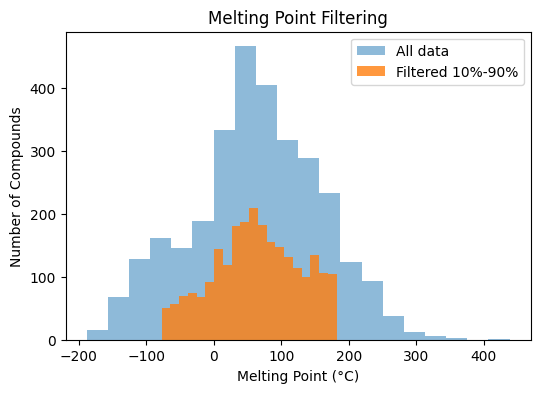

In [ ]:
# Assume df_clean is your dataset from Part C
mp_lower = df_desc["mpC"].quantile(0.1)
mp_upper = df_desc["mpC"].quantile(0.9)

df_mp_filtered = df_desc[(df_desc["mpC"] >= mp_lower) & (df_desc["mpC"] <= mp_upper)]

# Plot histogram of filtered mpC
plt.figure(figsize=(6,4))
plt.hist(df_desc["mpC"], bins=20, alpha=0.5, label="All data")
plt.hist(df_mp_filtered["mpC"], bins=20, alpha=0.8, label="Filtered 10%-90%")
plt.xlabel("Melting Point (°C)")
plt.ylabel("Number of Compounds")
plt.legend()
plt.title("Melting Point Filtering")
plt.show()


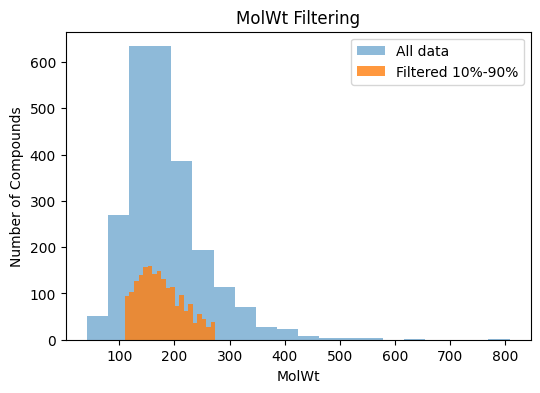

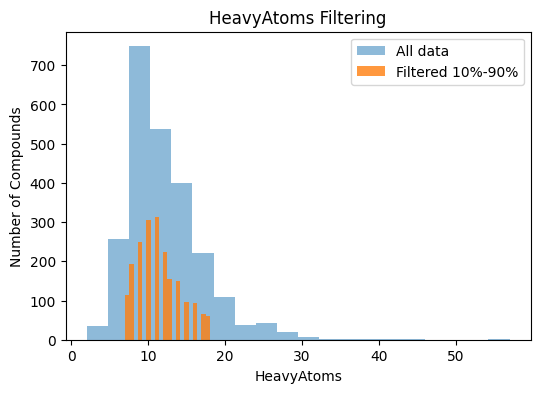

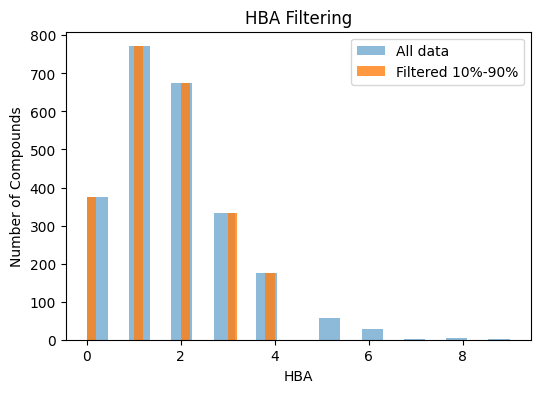

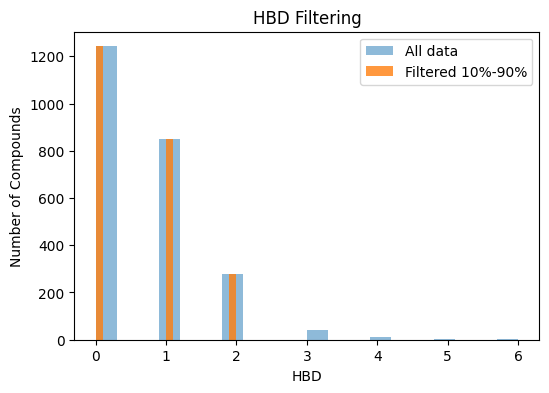

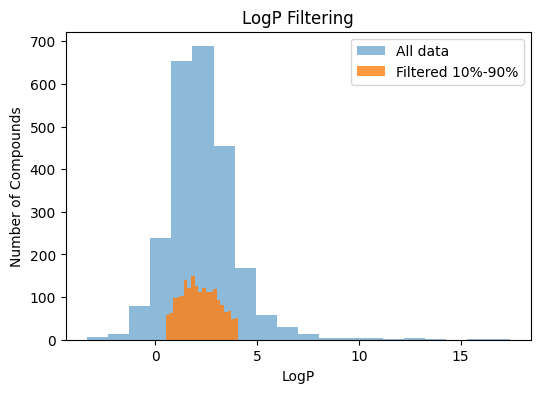

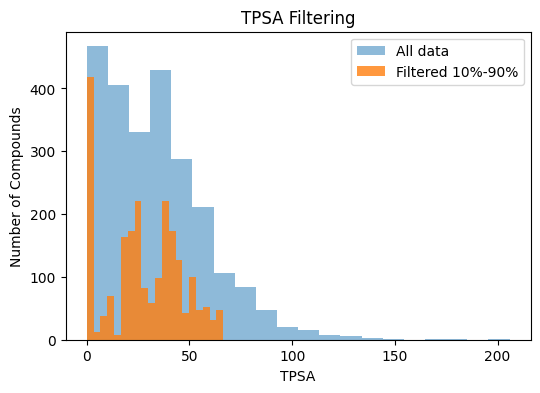

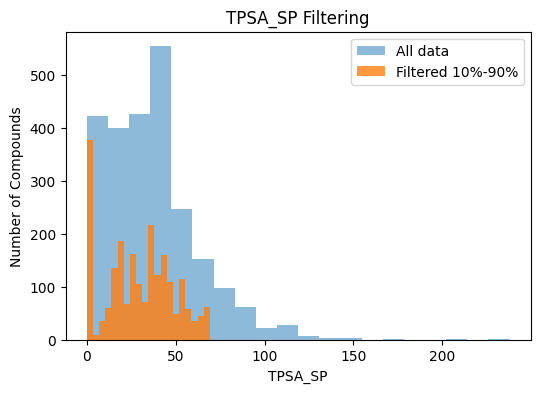

In [ ]:
properties = ["MolWt", "HeavyAtoms", "HBA", "HBD", "LogP", "TPSA", "TPSA_SP"]

df_filtered_dict = {}

for prop in properties:
    lower = df_mp_filtered[prop].quantile(0.1)
    upper = df_mp_filtered[prop].quantile(0.9)

    # Joint filtering: mpC already filtered
    df_filtered = df_mp_filtered[(df_mp_filtered[prop] >= lower) & (df_mp_filtered[prop] <= upper)]

    df_filtered_dict[prop] = df_filtered

    # Histogram for property
    plt.figure(figsize=(6,4))
    plt.hist(df_mp_filtered[prop], bins=20, alpha=0.5, label="All data")
    plt.hist(df_filtered[prop], bins=20, alpha=0.8, label="Filtered 10%-90%")
    plt.xlabel(prop)
    plt.ylabel("Number of Compounds")
    plt.legend()
    plt.title(f"{prop} Filtering")
    plt.show()


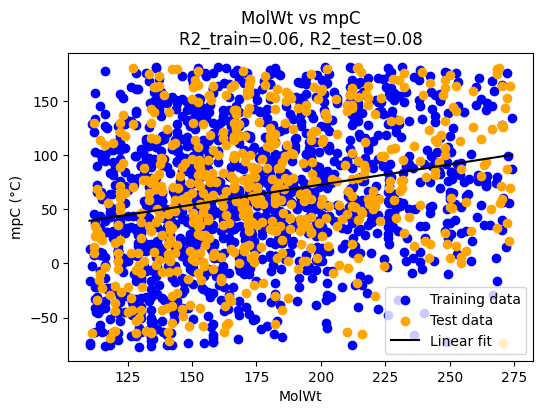

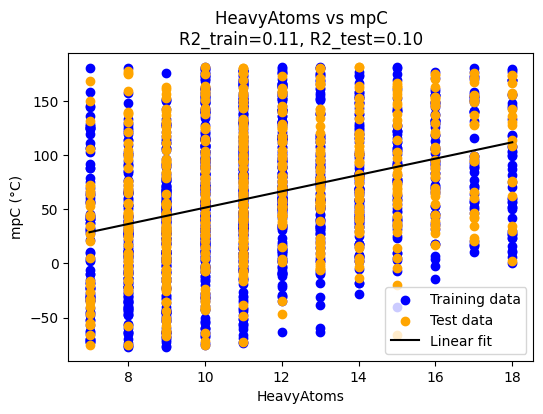

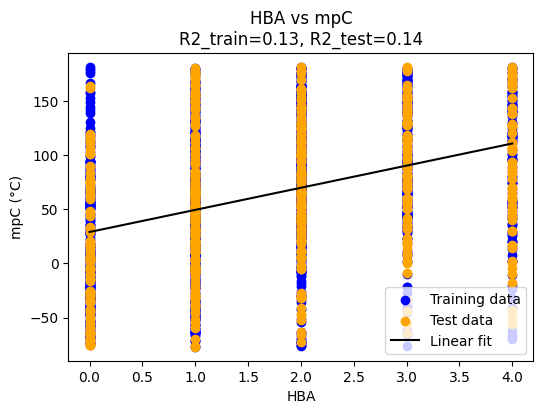

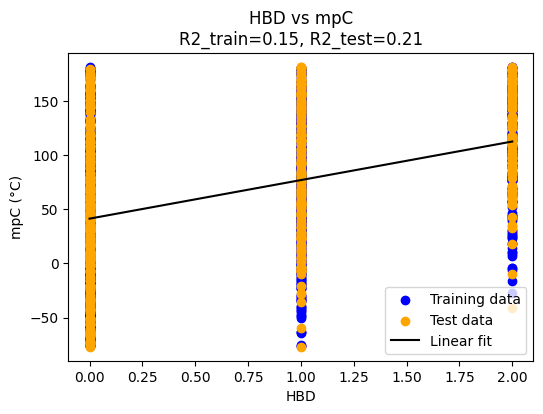

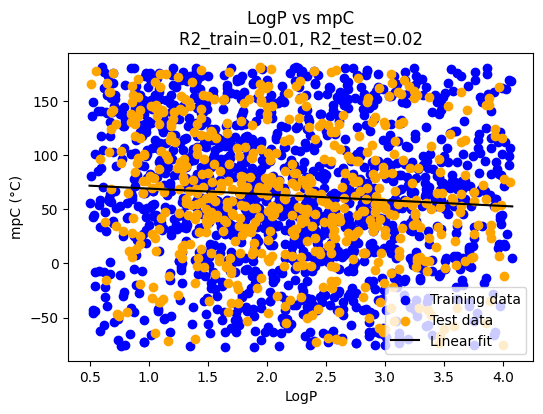

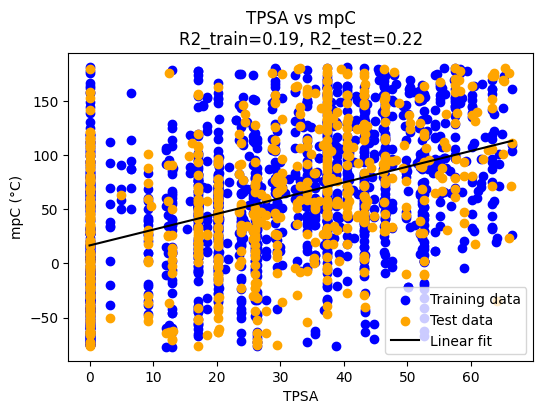

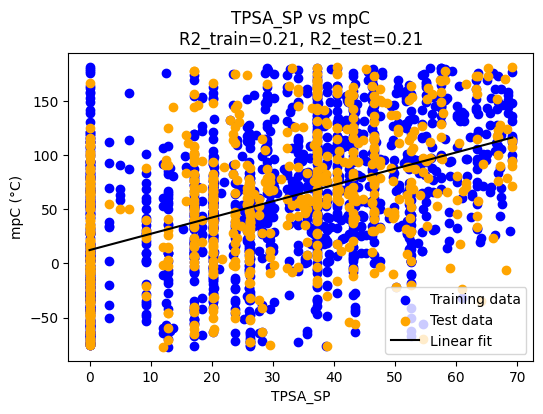

In [ ]:
results = {}

for prop in properties:
    df_filtered = df_filtered_dict[prop]

    X = df_filtered[[prop]].values  # predictor
    y = df_filtered["mpC"].values   # target

    # Train-test split(70/30)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Linear regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R2 scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    results[prop] = {"model": model, "r2_train": r2_train, "r2_test": r2_test}

    # Plot regression
    plt.figure(figsize=(6,4))
    plt.scatter(X_train, y_train, color="blue", label="Training data")
    plt.scatter(X_test, y_test, color="orange", label="Test data")

    # Plot regression line
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
    y_line = model.predict(x_line)
    plt.plot(x_line, y_line, color="black", label="Linear fit")

    plt.xlabel(prop)
    plt.ylabel("mpC (°C)")
    plt.title(f"{prop} vs mpC\nR2_train={r2_train:.2f}, R2_test={r2_test:.2f}")
    plt.legend()
    plt.show()


In [ ]:
# Print summary of R2 values
for prop in properties:
    print(f"{prop}: R2_train = {results[prop]['r2_train']:.2f}, R2_test = {results[prop]['r2_test']:.2f}")

MolWt: R2_train = 0.06, R2_test = 0.08
HeavyAtoms: R2_train = 0.11, R2_test = 0.10
HBA: R2_train = 0.13, R2_test = 0.14
HBD: R2_train = 0.15, R2_test = 0.21
LogP: R2_train = 0.01, R2_test = 0.02
TPSA: R2_train = 0.19, R2_test = 0.22
TPSA_SP: R2_train = 0.21, R2_test = 0.21


In [ ]:
best_props = ["TPSA", "TPSA_SP"]

E)

For two of the properties from D) (e.g., the ones that correlate best with the melting point), perform RANSAC regression, which is method that takes outliers into account when performing linear regression and does not include them in the final modeling, see here.

In the figure, it should be clear which data points are in inlier set and which are in the outlier set (e.g., by showing them in different colors).

Note: for some of the molecules, the TPSA descriptor will give a value of zero. When doing any analysis for the TPSA descriptor, you should ignore these values.

In [ ]:
#TPSA_SP exhibits the strongest correlation with melting temperature.
#TPSA and HBD also display moderate correlations than others.
#properties = ["TPSA_SP", "TPSA"]

def ransac_analysis(df, prop):
    # Ignore zero TPSA
    if prop in ["TPSA", "TPSA_SP"]:
        df = df[df[prop] > 0]

    X = df[[prop]].values
    y = df["mpC"].values

    base_model = LinearRegression()
    ransac = RANSACRegressor(
        base_model,
        min_samples=0.5,
        residual_threshold=5.0,
        random_state=0
    )

    ransac.fit(X, y)

    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask

    # Plot
    plt.scatter(X[inlier_mask], y[inlier_mask],
                label="Inliers", alpha=0.6)
    plt.scatter(X[outlier_mask], y[outlier_mask],
                label="Outliers", alpha=0.6)

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = ransac.predict(x_line)
    plt.plot(x_line, y_line, color="black")

    plt.xlabel(prop)
    plt.ylabel("Melting Point (°C)")
    plt.title(f"RANSAC regression: {prop}")
    plt.legend()
    plt.show()




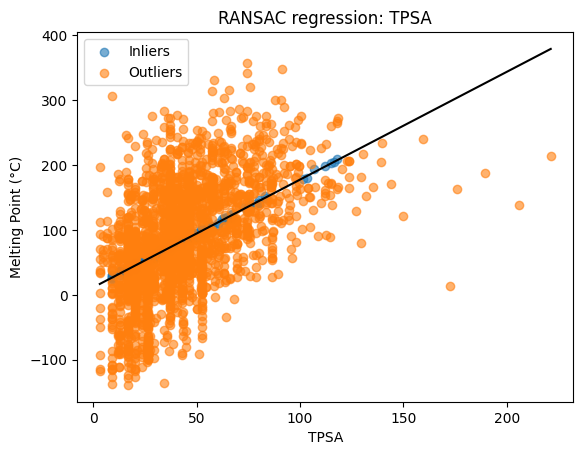

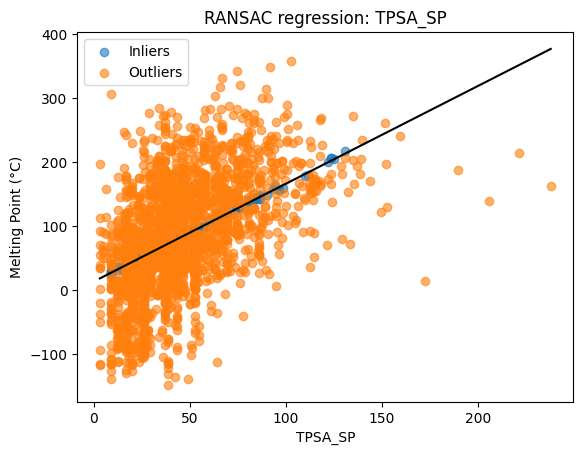

In [ ]:
 for prop in best_props:
    ransac_analysis(df_desc, prop)

### Task 2 - Optional 5 points

Here we will consider a dataset of two variables $x$ and $y$ sampled from a two-dimensional probability density $P(x,y)$ that is unknown.

The dataset is given as a time series in the file `Dataset_RotatedWQ-Potential.data`.

The main task is to perform a Gaussian Mixture Model analysis on this two-dimensional dataset.

#### A)
Plot the dataset, both the time series and also a scatter plot for the $x$ and $y$ variables.

Looking at the scatter plot, how many Gaussian components do you think are needed in the Gaussian Mixture Model analysis?

#### B)
Using Seaborn (or scikit-learn) estimate the two-dimensional probability density $P(x,y)$ using kernel density estimation.

#### C)
Perform a Gaussian Mixture Model analysis for a different number of components, and obtain the Bayesian information criterion (bic) and Akaike information criterion (aic) values and based on them identify the optimal number of components (remember that for both a lower value is better).

#### D)
For the optimal number of components, perform a final Gaussian Mixture Model analysis that you will analyze.

- What is the weight of each Gaussian components.

- What is the percentage of samples that are hard classifed to each cluster.

- Make a scatter plot that shows how the samples are hard classifed to each cluster. In this plot, indicate the center of each Gaussian components.

- Make figures that shows how the samples are soft classifed to each cluster (e.g., the probablity that they belong to a given cluster). In each plot, indicate the center of corresponding Gaussian components.

- Plot a two-dimensional surface of the $P(x,y)$ estimated by the Gaussian Mixture Model. How does this compare to the KDE plot from B)?


In [ ]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-2/"
dataset_filename="Dataset_RotatedWQ-Potential.data"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls



BradleyDoublePlusGoodMeltingPointDataset.csv
BradleyMP_with_descriptors.csv
Dataset_RotatedWQ-Potential.data
sample_data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler


In [ ]:
!head Dataset_RotatedWQ-Potential.data


#! FIELDS time p.x p.y
 0.000000 -1.174000 1.477000
 1.000000 -1.623929 0.606506
 2.000000 -1.888162 0.751783
 3.000000 -1.726908 0.444591
 4.000000 -1.553645 0.260369
 5.000000 -1.677539 0.801004
 6.000000 -2.042513 0.999498
 7.000000 -1.518738 1.228479
 8.000000 -1.520207 0.469390


In [ ]:
# Load data (skip first line if it's a header)
df = pd.read_csv("Dataset_RotatedWQ-Potential.data", delim_whitespace=True, comment='#', names=["time", "x", "y"])

/tmp/ipython-input-4113852260.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("Dataset_RotatedWQ-Potential.data", delim_whitespace=True, comment='#', names=["time", "x", "y"])


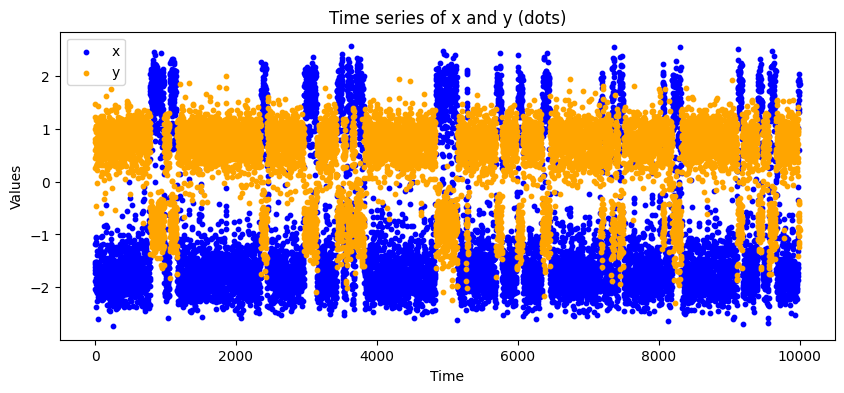

In [ ]:
# Time series plot with dots
plt.figure(figsize=(10,4))
plt.scatter(df['time'], df['x'], label='x', color='blue' ,s=10)  # s = marker size
plt.scatter(df['time'], df['y'], label='y', color='orange', s=10)
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Time series of x and y (dots)')
plt.legend()
plt.show()


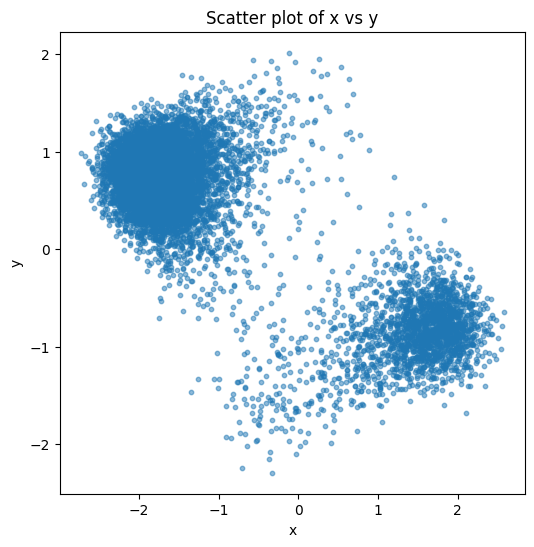

In [ ]:
# Scatter plot of x vs y
plt.figure(figsize=(6,6))
plt.scatter(df['x'], df['y'], s=10, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x vs y')
plt.show()


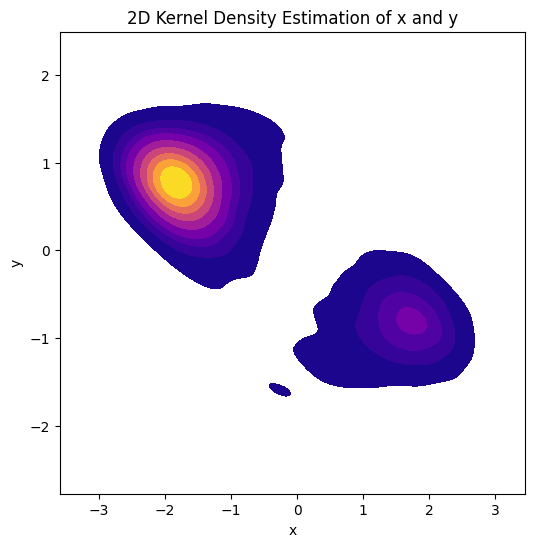

In [ ]:
# B) Estimate 2D probability density (KDE)
# --------------------------------------
plt.figure(figsize=(6,6))
sns.kdeplot(x=df['x'], y=df['y'], fill=True, cmap='plasma', levels=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Kernel Density Estimation of x and y')
plt.show()


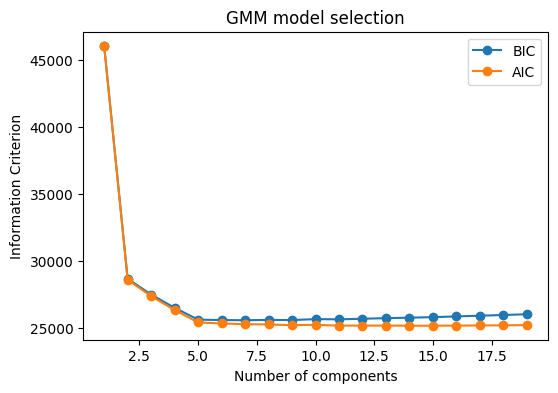

Optimal number of GMM components: 7


In [ ]:
#C) GMM analysis: find optimal components

X = df[['x', 'y']].values
X_scaled = StandardScaler().fit_transform(X)  # scale data for stability

bic_list = []
aic_list = []
n_components_range = range(1, 20)  # try 1 to 6 components

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(X_scaled)
    bic_list.append(gmm.bic(X_scaled))
    aic_list.append(gmm.aic(X_scaled))

# Plot BIC and AIC
plt.figure(figsize=(6,4))
plt.plot(n_components_range, bic_list, label='BIC', marker='o')
plt.plot(n_components_range, aic_list, label='AIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('Information Criterion')
plt.title('GMM model selection')
plt.legend()
plt.show()

# Choose the optimal number of components (lowest BIC)
optimal_n = n_components_range[np.argmin(bic_list)]
print("Optimal number of GMM components:", optimal_n)

GMM component weights: [0.10200786 0.15802171 0.24873698 0.06909767 0.04841584 0.1378898
 0.23583014]
Percentage of samples in cluster 0: 7.64%
Percentage of samples in cluster 1: 16.31%
Percentage of samples in cluster 2: 28.33%
Percentage of samples in cluster 3: 4.57%
Percentage of samples in cluster 4: 4.30%
Percentage of samples in cluster 5: 11.57%
Percentage of samples in cluster 6: 27.29%


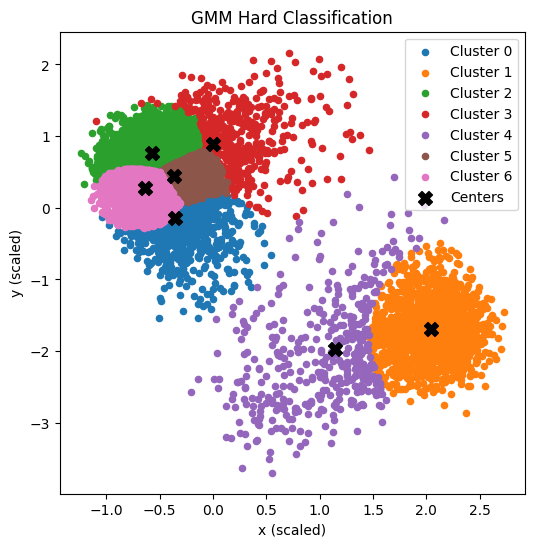

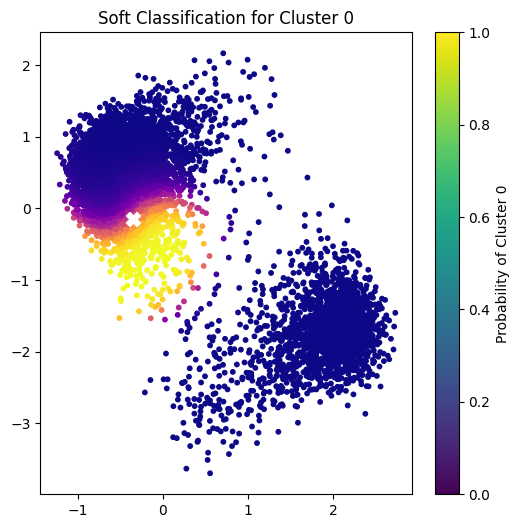

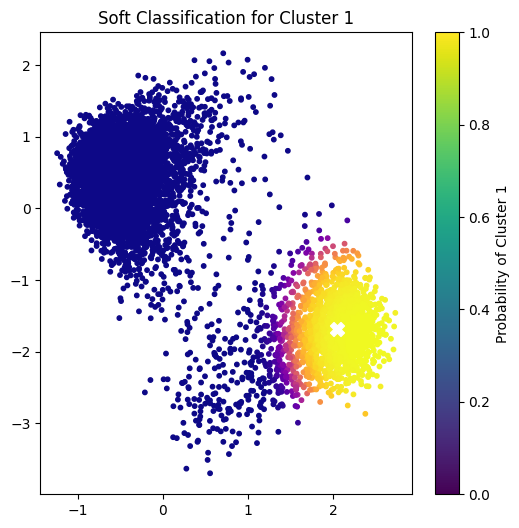

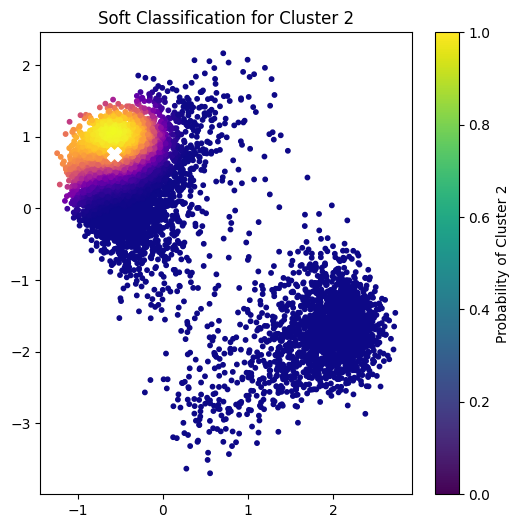

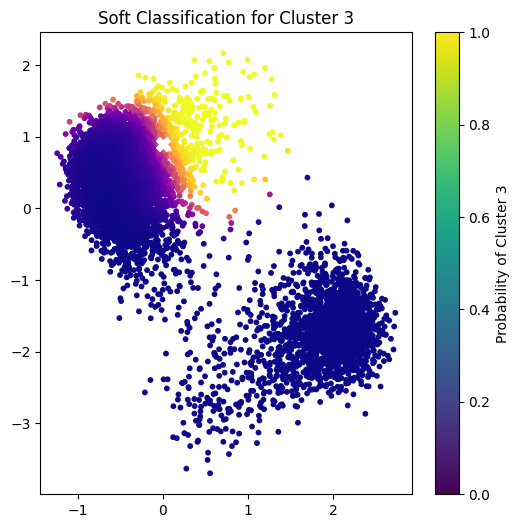

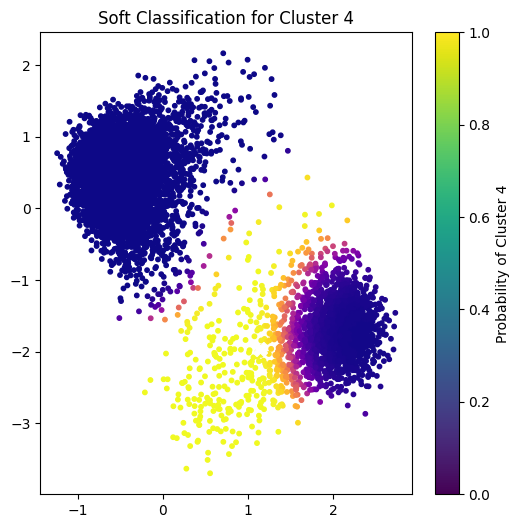

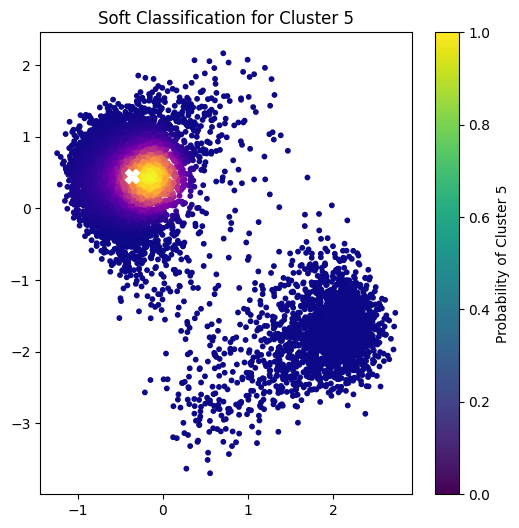

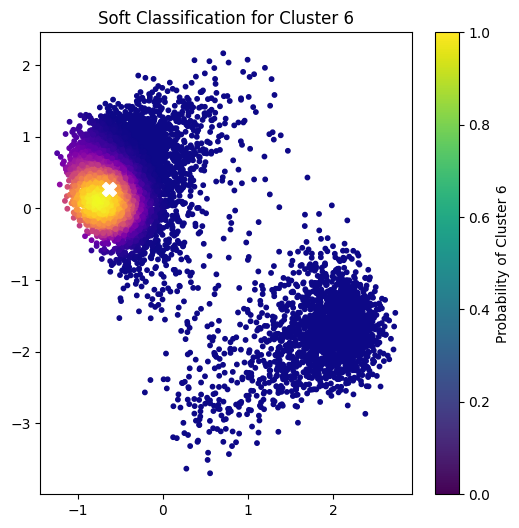

In [ ]:
# D) Fit GMM with optimal components

gmm_opt = GaussianMixture(n_components=optimal_n, random_state=0)
gmm_opt.fit(X_scaled)

# Get weights
print("GMM component weights:", gmm_opt.weights_)

# Hard classification
labels = gmm_opt.predict(X_scaled)
for i in range(optimal_n):
    print(f"Percentage of samples in cluster {i}: {100*np.sum(labels==i)/len(labels):.2f}%")

# Scatter plot with hard classification
plt.figure(figsize=(6,6))
for i in range(optimal_n):
    plt.scatter(X_scaled[labels==i,0], X_scaled[labels==i,1], s=20, label=f'Cluster {i}')
plt.scatter(gmm_opt.means_[:,0], gmm_opt.means_[:,1], c='black', marker='X', s=100, label='Centers')
plt.xlabel('x (scaled)')
plt.ylabel('y (scaled)')
plt.title('GMM Hard Classification')
plt.legend()
plt.show()

# Soft classification: probability of belonging to each cluster
probs = gmm_opt.predict_proba(X_scaled)
for i in range(optimal_n):
    plt.figure(figsize=(6,6))
    plt.scatter(X_scaled[:,0], X_scaled[:,1], c=probs[:,i], cmap='plasma', s=10)
    plt.scatter(gmm_opt.means_[i,0], gmm_opt.means_[i,1], c='white', marker='X', s=100)
    plt.colorbar(label=f'Probability of Cluster {i}')
    plt.title(f'Soft Classification for Cluster {i}')
    plt.show()

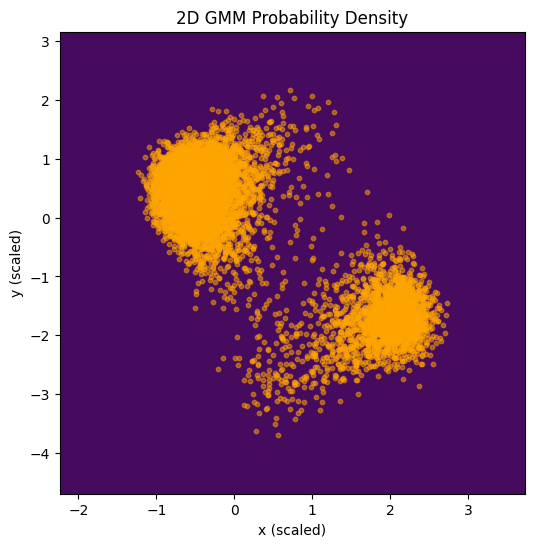

In [ ]:
# E) 2D surface plot of GMM density
# Create grid
x = np.linspace(X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, 100)
y = np.linspace(X_scaled[:,1].min()-1, X_scaled[:,1].max()+1, 100)
X_grid, Y_grid = np.meshgrid(x, y)
XY_grid = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# Evaluate density
Z = np.exp(gmm_opt.score_samples(XY_grid)).reshape(100,100)

# Plot
plt.figure(figsize=(6,6))
plt.contourf(X_grid, Y_grid, Z, levels=20)
plt.scatter(X_scaled[:,0], X_scaled[:,1], s=10, color='orange', alpha=0.5)
plt.xlabel('x (scaled)')
plt.ylabel('y (scaled)')
plt.title('2D GMM Probability Density')
plt.show()